# KRYPTON: TokenTrend

**The Pipeline**
1. Data loading & cleaning for all 23 coins
2. Automatic coin categorisation (Stablecoin / DeFi-new / Volatile-momentum)
3. Category-specific feature engineering
4. Feature selection
5. Train/test split strategy selection (Walk-forward TimeSeriesSplit)
6. Three separate model pipelines (one per category)
7. Evaluation on held-out test samples
8. Final `predict_coin(filepath)` function for the unknown test file
9. Model export to JSON for frontend client-side inference

---
> **Design principle:** coin *type* determines *feature priority*, not model type.
> We use the same soft-voting ensemble everywhere but switch feature sets by category.
> A lightweight regime detector auto-routes any unknown coin to the right pipeline.

## 0. Dependencies

In [38]:
import os
import json
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing     import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.model_selection   import TimeSeriesSplit, cross_val_score
from sklearn.metrics           import (accuracy_score, precision_score,
                                       recall_score, f1_score,
                                       classification_report, confusion_matrix)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection        import permutation_importance

# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Data Loading & Cleaning

We load all CSV files from the project directory, standardise column types,
remove duplicates, sort by date, and flag any anomalous rows.

In [39]:
# ── 1.1  Locating all coin CSV files ────────────────────────────────────────────
DATA_DIR = '.'
csv_files = glob.glob(os.path.join(DATA_DIR, 'coin_*.csv'))
print(f'Found {len(csv_files)} coin files.')

# ── 1.2  Loading & cleaning each file ───────────────────────────────────────────────
def load_and_clean(filepath: str) -> pd.DataFrame:
    """
    Load a single coin CSV and apply standardised cleaning:
      - Parse dates, set as index
      - Drop exact duplicate rows
      - Forward-fill missing OHLCV values (at most 2 consecutive)
      - Drop rows where Volume == 0 AND it's not a stablecoin
        (zero-volume days on volatile coins are suspicious / exchange outages)
      - Reset to a clean DatetimeIndex sorted ascending
    """
    name = os.path.basename(filepath).replace('coin_', '').replace('.csv', '')
    df = pd.read_csv(filepath, parse_dates=['Date'])
    df.columns = [c.strip() for c in df.columns]

    # Sorting chronologically
    df = df.sort_values('Date').drop_duplicates(subset='Date').reset_index(drop=True)
    df.set_index('Date', inplace=True)

    # Forward-fill gaps (max 2 days; longer gaps stay NaN and get dropped)
    df = df.ffill(limit=2)
    df.dropna(inplace=True)

    df['Coin'] = name
    return df

all_coins: dict[str, pd.DataFrame] = {}
for f in sorted(csv_files):
    name = os.path.basename(f).replace('coin_', '').replace('.csv', '')
    all_coins[name] = load_and_clean(f)

# ── 1.3  Summary ──────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Rows'     : {k: len(v) for k, v in all_coins.items()},
    'Start'    : {k: v.index.min().date() for k, v in all_coins.items()},
    'End'      : {k: v.index.max().date() for k, v in all_coins.items()},
    'Nulls'    : {k: v.isnull().sum().sum() for k, v in all_coins.items()},
})
print(summary.to_string())

Found 23 coin files.
                Rows       Start         End  Nulls
Aave             275  2020-10-05  2021-07-06      0
BinanceCoin     1442  2017-07-26  2021-07-06      0
Bitcoin         2991  2013-04-29  2021-07-06      0
Cardano         1374  2017-10-02  2021-07-06      0
ChainLink       1385  2017-09-21  2021-07-06      0
Cosmos           845  2019-03-15  2021-07-06      0
CryptocomCoin    935  2018-12-15  2021-07-06      0
Dogecoin        2760  2013-12-16  2021-07-06      0
EOS             1466  2017-07-02  2021-07-06      0
Ethereum        2160  2015-08-08  2021-07-06      0
Iota            1484  2017-06-14  2021-07-06      0
Litecoin        2991  2013-04-29  2021-07-06      0
Monero          2602  2014-05-22  2021-07-06      0
NEM             2288  2015-04-02  2021-07-06      0
Polkadot         320  2020-08-21  2021-07-06      0
Solana           452  2020-04-11  2021-07-06      0
Stellar         2527  2014-08-06  2021-07-06      0
Tether          2318  2015-02-26  2021-07-0

---
## 2. Coin Categorisation (Regime Detection)

Rather than hardcoding which coin belongs to which category, we use a
**data-driven regime detector** so that the same function works on any
unknown test coin at inference time.

| Category | Detection rule | Model strategy |
|---|---|---|
| Stablecoin | Price range < 10 % of mean price | Peg-distance features, RF+GBM only |
| Short-DeFi | < 600 rows of data | Heavy L2 regularisation, LogReg dominant |
| Volatile | Everything else | Full soft-voting ensemble, momentum features |

In [40]:
def categorise_coin(df: pd.DataFrame) -> str:
    """
    Returns one of: 'stablecoin', 'defi_short', 'volatile'

    Logic:
      1. If the full price range (max-min) is less than 10% of the mean price
         → stablecoin (price hugs a peg)
      2. Else if fewer than 600 clean rows
         → defi_short (not enough history for deep trees)
      3. Else → volatile (standard momentum-driven coin)
    """

    q25 = df['Close'].quantile(0.25)
    q75 = df['Close'].quantile(0.75)
    iqr_range = q75 - q25
    median_price = df['Close'].median()
    relative_range = iqr_range / median_price # IQR as % of median
    if relative_range < 0.05:       # middle 50% of prices within 5% of median
        return 'stablecoin'
    elif len(df) < 600:
        return 'defi_short'
    else:
        return 'volatile'

# Applying to all coins
categories = {name: categorise_coin(df) for name, df in all_coins.items()}

# Displaying the categorisation
cat_df = pd.DataFrame.from_dict(categories, orient='index', columns=['Category'])
cat_df['Rows'] = [len(all_coins[n]) for n in cat_df.index]
print(cat_df.sort_values('Category').to_string())

# Partition the coin dictionary by category for convenience
stable_coins  = {n: all_coins[n] for n, c in categories.items() if c == 'stablecoin'}
defi_coins    = {n: all_coins[n] for n, c in categories.items() if c == 'defi_short'}
volatile_coins= {n: all_coins[n] for n, c in categories.items() if c == 'volatile'}

print(f'\nStablecoin  : {list(stable_coins.keys())}')
print(f'DeFi-short  : {list(defi_coins.keys())}')
print(f'Volatile    : {list(volatile_coins.keys())}')

                  Category  Rows
Aave            defi_short   275
Uniswap         defi_short   292
Solana          defi_short   452
Polkadot        defi_short   320
USDCoin         stablecoin  1002
Tether          stablecoin  2318
Tron              volatile  1392
Stellar           volatile  2527
NEM               volatile  2288
Monero            volatile  2602
WrappedBitcoin    volatile   888
Litecoin          volatile  2991
Ethereum          volatile  2160
EOS               volatile  1466
Dogecoin          volatile  2760
CryptocomCoin     volatile   935
Cosmos            volatile   845
ChainLink         volatile  1385
Cardano           volatile  1374
Bitcoin           volatile  2991
BinanceCoin       volatile  1442
Iota              volatile  1484
XRP               volatile  2893

Stablecoin  : ['Tether', 'USDCoin']
DeFi-short  : ['Aave', 'Polkadot', 'Solana', 'Uniswap']
Volatile    : ['BinanceCoin', 'Bitcoin', 'Cardano', 'ChainLink', 'Cosmos', 'CryptocomCoin', 'Dogecoin', 'EOS', 'Eth

---
## 3. Feature Engineering

We define **three feature sets** — one per category.
All features are purely backward-looking (no lookahead bias).

### Shared base features (all coins)
- Daily return, log return, high-low range, open-close body
- Lag returns (1, 2, 3 days)
- Rolling volatility (5-day std of returns)

### Volatile-only momentum features
- RSI-14
- MA5 / MA20 crossover signal
- Bollinger Band position
- Volume spike flag
- BTC lag-1 return (cross-coin signal)
- ATR-normalised range

### Stablecoin peg-mechanics features
- Distance from $1.00 peg
- 5-day rolling mean of peg distance
- Binary below-peg / above-peg flags

> **Target variable** `y`: 1 = next day's Close > today's Close (UP), 0 = DOWN

In [41]:
# We will pre-compute Bitcoin daily returns once — used as cross-coin signal for volatile coins
btc_returns = all_coins['Bitcoin']['Close'].pct_change().rename('BTC_lag1').shift(1)

def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """Relative Strength Index."""
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def engineer_features(df: pd.DataFrame, category: str,
                      btc_ret: pd.Series = None) -> pd.DataFrame:
    """
    Now we build a feature matrix from a cleaned OHLCV DataFrame.

    Parameters
    ----------
    df       : cleaned OHLCV DataFrame with DatetimeIndex
    category : 'stablecoin' | 'defi_short' | 'volatile'
    btc_ret  : optional Series of BTC lag-1 returns (for volatile coins)

    Returns
    -------
    feat : DataFrame of features with a binary target column 'Target'
    """
    feat = pd.DataFrame(index=df.index)
    close = df['Close']
    open_safe = df['Open'].replace(0, np.nan)

    # ── BASE features (all categories) ────────────────────────────────────────
    feat['Return']       = df['Close'].pct_change()                     # daily % return
    feat['LogReturn']    = np.log(df['Close'] / df['Close'].shift(1))   # log return
    feat['HL_Range']     = (df['High'] - df['Low']) / df['Close']       # high-low normalised
    feat['OC_Body']      = (df['Close'] - df['Open']) / df['Open']      # candle body
    feat['Lag1_Return']  = feat['Return'].shift(1)
    feat['Lag2_Return']  = feat['Return'].shift(2)
    feat['Lag3_Return']  = feat['Return'].shift(3)
    feat['Volatility5']  = feat['Return'].rolling(5).std()              # 5-day rolling vol
    feat['Volume_change']= df['Volume'].pct_change()                    # volume momentum

    # ── VOLATILE / DEFI-SHORT momentum features ────────────────────────────────
    if category in ('volatile', 'defi_short'):
        # RSI-14
        feat['RSI14'] = compute_rsi(df['Close'], 14)

        # Moving average crossover: 1 when fast MA is above slow MA
        ma5  = df['Close'].rolling(5).mean()
        ma20 = df['Close'].rolling(20).mean()
        feat['MA_Cross'] = (ma5 > ma20).astype(int)

        # Bollinger Band position: where is Close within the band... (0 = lower, 1 = upper)
        ma20_std = df['Close'].rolling(20).std()
        upper_bb = ma20 + 2 * ma20_std
        lower_bb = ma20 - 2 * ma20_std
        band_width = (upper_bb - lower_bb).replace(0, np.nan)
        feat['BB_Position'] = (close - lower_bb) / band_width

        # Volume spike: is today's volume > 1.5× the 10-day average...
        vol_ma10 = df['Volume'].rolling(10).mean().replace(0, np.nan)
        feat['Vol_Spike'] = (df['Volume'] > 1.5 * vol_ma10).astype(int)

        # ATR-normalised range (Average True Range, 14-day)
        high_low   = df['High'] - df['Low']
        high_close = (df['High'] - df['Close'].shift(1)).abs()
        low_close  = (df['Low']  - df['Close'].shift(1)).abs()
        tr  = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        atr = tr.rolling(14).mean()
        feat['ATR_norm'] = atr / close.replace(0, np.nan)                            # normalised ATR

        # BTC lag-1 return (cross-coin signal; only for non-BTC coins)
        if btc_ret is not None:
            feat['BTC_lag1'] = btc_ret.reindex(feat.index)             # align on dates

    # ── STABLECOIN peg-mechanics features ─────────────────────────────────────
    if category == 'stablecoin':
        feat['Dev_from_peg']  = close - 1.0                      # signed deviation
        feat['Abs_dev_peg']   = feat['Dev_from_peg'].abs()
        feat['Peg_MA5']       = feat['Dev_from_peg'].rolling(5).mean() # 5-day trend of dev
        feat['Below_peg']     = (close < 0.999).astype(int)      # at discount
        feat['Above_peg']     = (close > 1.001).astype(int)      # at premium

    # ── TARGET: 1 if tomorrow's Close > today's Close ─────────────────────────
    feat['Target'] = (close.shift(-1) > close).astype(int)

    # Dropping NaN rows (from rolling windows and lag features)
    feat.replace([np.inf, -np.inf], np.nan, inplace=True)
    feat.dropna(inplace=True)

    # Clip outliers to ±10 std — stabilises scaler and tree splits on spike coins like Dogecoin 2021 without removing real data points
    for col in feat.columns:
        if col == 'Target':
            continue
        std = feat[col].std()
        if std > 0:
            mean = feat[col].mean()
            feat[col] = feat[col].clip(lower=mean - 10*std, upper=mean + 10*std)
    # Dropping the last row (Target is NaN because we don't have tomorrow yet)
    feat = feat.iloc[:-1]

    return feat


# Building feature matrices for every coin
feature_sets: dict[str, pd.DataFrame] = {}

for name, df in all_coins.items():
    cat = categories[name]
    btc = btc_returns if (name != 'Bitcoin' and cat in ('volatile', 'defi_short')) else None
    feature_sets[name] = engineer_features(df, cat, btc)

# Quick check
sample = feature_sets['Bitcoin']
print(f'Bitcoin features: {list(sample.columns)}')
print(f'Shape            : {sample.shape}')
print(f'Target balance   : {sample["Target"].value_counts(normalize=True).round(3).to_dict()}')

Bitcoin features: ['Return', 'LogReturn', 'HL_Range', 'OC_Body', 'Lag1_Return', 'Lag2_Return', 'Lag3_Return', 'Volatility5', 'Volume_change', 'RSI14', 'MA_Cross', 'BB_Position', 'Vol_Spike', 'ATR_norm', 'Target']
Shape            : (2747, 15)
Target balance   : {1: 0.536, 0: 0.464}


---
## 4. Feature Selection

We use **ANOVA F-score** (`SelectKBest`) to rank features by their linear
association with the target, then keep the top-K.

Why not correlation alone? F-score also captures features that differ in variance
between classes, which is useful for volume and volatility features.

We run selection **inside** the training fold to prevent any data leakage.

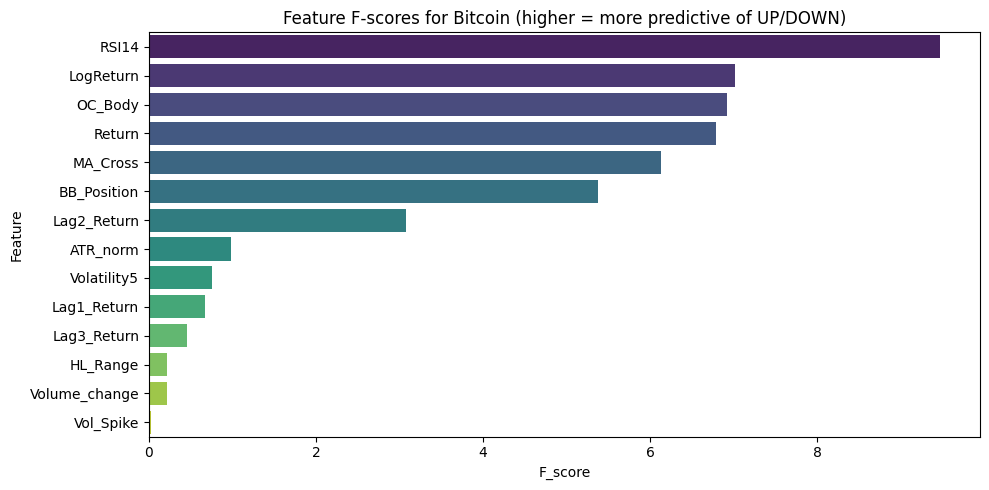

      Feature  F_score
        RSI14 9.477027
    LogReturn 7.015584
      OC_Body 6.922607
       Return 6.790454
     MA_Cross 6.129481
  BB_Position 5.374208
  Lag2_Return 3.076752
     ATR_norm 0.986882
  Volatility5 0.752823
  Lag1_Return 0.672174
  Lag3_Return 0.461939
     HL_Range 0.219543
Volume_change 0.214783
    Vol_Spike 0.021117


In [42]:
def select_features(X_train: pd.DataFrame, y_train: pd.Series,
                    X_test: pd.DataFrame,
                    k: int = 10) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """
    Fitting SelectKBest on training data only, then transforming both splits.
    Returns (X_train_sel, X_test_sel, selected_feature_names).
    k is capped at the number of available features.
    """
    k = min(k, X_train.shape[1])
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    mask  = selector.get_support()
    names = list(X_train.columns[mask])
    return (pd.DataFrame(selector.transform(X_train), columns=names, index=X_train.index),
            pd.DataFrame(selector.transform(X_test),  columns=names, index=X_test.index),
            names)


# ── Visualising feature importance for Bitcoin as an illustration ───────────────
feat_btc = feature_sets['Bitcoin'].copy()
X_all = feat_btc.drop(columns='Target')
y_all = feat_btc['Target']

sel = SelectKBest(f_classif, k=X_all.shape[1]).fit(X_all, y_all)
importance_df = pd.DataFrame({
    'Feature': X_all.columns,
    'F_score': sel.scores_
}).sort_values('F_score', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='F_score', y='Feature', palette='viridis')
plt.title('Feature F-scores for Bitcoin (higher = more predictive of UP/DOWN)')
plt.tight_layout()
plt.show()
print(importance_df.to_string(index=False))

---
## 5. Train / Test Split Strategy

### Why Walk-Forward (TimeSeriesSplit) over 80-20 random split?

Random 80-20 split **shuffles** the data, meaning the model sees future data
during training and is evaluated on the past. This produces optimistically
inflated accuracy on financial time series — a classic data-leakage trap.

**TimeSeriesSplit** (walk-forward validation) always trains on the past and
tests on the future, mimicking real deployment. We use:
- **5 folds** for coins with > 600 rows
- **3 folds** for short DeFi coins (< 600 rows)

We also hold out the **last 20% of each coin's data** as a final out-of-sample
test set that is never touched during cross-validation.

In [43]:
def temporal_train_test_split(feat_df: pd.DataFrame,
                               test_ratio: float = 0.20
                               ) -> tuple[pd.DataFrame, pd.Series,
                                          pd.DataFrame, pd.Series]:
    """
    Chronological split: first (1 - test_ratio) rows → train,
                         last test_ratio rows       → test.
    No shuffling. Preserves temporal order.
    """
    split_idx = int(len(feat_df) * (1 - test_ratio))
    train = feat_df.iloc[:split_idx]
    test  = feat_df.iloc[split_idx:]
    return (train.drop(columns='Target'), train['Target'],
            test.drop(columns='Target'),  test['Target'])


# Pre-split all coins
splits: dict = {}
for name, feat_df in feature_sets.items():
    splits[name] = temporal_train_test_split(feat_df)

print('Splits created for all coins.')
for name, (X_tr, y_tr, X_te, y_te) in splits.items():
    print(f'  {name:20s}  train={len(X_tr):4d}  test={len(X_te):4d}  "\
         f"test_UP%={y_te.mean():.2f}')

Splits created for all coins.
  Aave                  train= 204  test=  51  "         f"test_UP%=0.51
  BinanceCoin           train=1137  test= 285  "         f"test_UP%=0.55
  Bitcoin               train=2197  test= 550  "         f"test_UP%=0.54
  Cardano               train=1083  test= 271  "         f"test_UP%=0.54
  ChainLink             train=1092  test= 273  "         f"test_UP%=0.54
  Cosmos                train= 660  test= 165  "         f"test_UP%=0.50
  CryptocomCoin         train= 732  test= 183  "         f"test_UP%=0.55
  Dogecoin              train=2192  test= 548  "         f"test_UP%=0.50
  EOS                   train=1156  test= 290  "         f"test_UP%=0.50
  Ethereum              train=1712  test= 428  "         f"test_UP%=0.57
  Iota                  train=1171  test= 293  "         f"test_UP%=0.54
  Litecoin              train=2197  test= 550  "         f"test_UP%=0.53
  Monero                train=2065  test= 517  "         f"test_UP%=0.56
  NEM                

---
## 6. Model Definitions

We define **three soft-voting ensembles**, one per category.
Each is a sklearn `Pipeline` with scaling → model inside each voter.

### Why soft voting?
Soft voting averages the *predicted probability* of UP across all base models
before making the final call. This:
- Produces a confidence percentage (great for dashboard display)
- Is more calibrated than hard (majority) voting
- Lets a linear model (LogReg) and a tree model (GBM) complement each other

In [44]:
def make_volatile_ensemble() -> VotingClassifier:
    """
    Full ensemble for momentum-driven volatile coins.
    Three diverse base learners: LogReg + RandomForest + GradientBoosting.
    """
    lr  = Pipeline([('scaler', StandardScaler()),
                    ('model',  LogisticRegression(C=0.1, max_iter=500,
                                                  random_state=RANDOM_STATE))])
    rf  = RandomForestClassifier(n_estimators=200, max_depth=5,
                                 min_samples_leaf=10, random_state=RANDOM_STATE)
    gbm = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                     learning_rate=0.05, subsample=0.8,
                                     random_state=RANDOM_STATE)
    return VotingClassifier(
        estimators=[('lr', lr), ('rf', rf), ('gbm', gbm)],
        voting='soft'
    )


def make_defi_ensemble() -> VotingClassifier:
    """
    Conservative ensemble for short-history DeFi coins (<600 rows).
    Heavy regularisation on LogReg; shallow trees to prevent overfitting.
    """
    lr  = Pipeline([('scaler', StandardScaler()),
                    ('model',  LogisticRegression(C=0.01, max_iter=500,
                                                  random_state=RANDOM_STATE))])
    rf  = RandomForestClassifier(n_estimators=100, max_depth=3,
                                 min_samples_leaf=15, random_state=RANDOM_STATE)
    gbm = GradientBoostingClassifier(n_estimators=100, max_depth=2,
                                     learning_rate=0.05, subsample=0.7,
                                     random_state=RANDOM_STATE)
    return VotingClassifier(
        estimators=[('lr', lr), ('rf', rf), ('gbm', gbm)],
        voting='soft'
    )


def make_stable_ensemble() -> VotingClassifier:
    """
    Peg-mechanics ensemble for stablecoins.
    LogReg is EXCLUDED (can't handle class imbalance on peg coins).
    RF and GBM both use class_weight / sample weights to handle imbalance.
    """
    rf  = RandomForestClassifier(n_estimators=200, max_depth=4,
                                 min_samples_leaf=5,
                                 class_weight='balanced',
                                 random_state=RANDOM_STATE)
    gbm = GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                     learning_rate=0.05, subsample=0.8,
                                     random_state=RANDOM_STATE)
    return VotingClassifier(
        estimators=[('rf', rf), ('gbm', gbm)],
        voting='soft'
    )


MODEL_FACTORIES = {
    'volatile'   : make_volatile_ensemble,
    'defi_short' : make_defi_ensemble,
    'stablecoin' : make_stable_ensemble,
}

print('Model factories defined for all three categories.')

Model factories defined for all three categories.


---
## 7. Training, Cross-Validation & Evaluation

For each coin:
1. Select top features (fit on train only)
2. Run TimeSeriesSplit cross-validation on the **training** portion
3. Fit the final model on the full training set
4. Evaluate on the held-out **test** set

Metrics reported: Accuracy, Precision, Recall, F1

In [45]:
def evaluate_coin(name: str, verbose: bool = True) -> dict:
    """
    Full training & evaluation pipeline for a single coin.

    Returns a dict with CV scores and held-out test metrics.
    """
    cat               = categories[name]
    X_train, y_train, X_test, y_test = splits[name]

    # ── Feature selection (fit on train only) ─────────────────────────────────
    k = 12 if cat == 'volatile' else 8   # fewer features for short/stable coins
    X_tr_sel, X_te_sel, chosen_feats = select_features(X_train, y_train, X_test, k=k)

    # ── Cross-validation on training data ─────────────────────────────────────
    n_splits = 3 if cat == 'defi_short' else 5
    tscv     = TimeSeriesSplit(n_splits=n_splits)
    model_cv = MODEL_FACTORIES[cat]()

    cv_scores = cross_val_score(model_cv, X_tr_sel, y_train,
                                cv=tscv, scoring='accuracy', n_jobs=-1)

    # ── Final fit on full training set ────────────────────────────────────────
    model_final = MODEL_FACTORIES[cat]()
    model_final.fit(X_tr_sel, y_train)

    # ── Held-out test evaluation ───────────────────────────────────────────────
    y_pred = model_final.predict(X_te_sel)
    y_prob = model_final.predict_proba(X_te_sel)[:, 1]  # probability of UP

    result = {
        'coin'          : name,
        'category'      : cat,
        'n_train'       : len(X_train),
        'n_test'        : len(X_test),
        'cv_mean_acc'   : cv_scores.mean().round(4),
        'cv_std_acc'    : cv_scores.std().round(4),
        'test_accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'test_precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'test_recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'test_f1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'features_used' : chosen_feats,
        'model'         : model_final,
        'X_test'        : X_te_sel,
        'y_test'        : y_test,
        'y_pred'        : y_pred,
        'y_prob'        : y_prob,
    }

    if verbose:
        print(f'[{name:20s}] cat={cat:12s}  '
              f'CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}  '
              f'Test Acc={result["test_accuracy"]:.3f}  '
              f'Prec={result["test_precision"]:.3f}  '
              f'F1={result["test_f1"]:.3f}')

    return result


# ── Run pipeline for ALL coins ─────────────────────────────────────────────────
print('Training models for all 23 coins...\n')
results: dict[str, dict] = {}
for name in all_coins:
    results[name] = evaluate_coin(name)

Training models for all 23 coins...

[Aave                ] cat=defi_short    CV=0.549±0.058  Test Acc=0.529  Prec=0.522  F1=0.667
[BinanceCoin         ] cat=volatile      CV=0.546±0.036  Test Acc=0.519  Prec=0.559  F1=0.581
[Bitcoin             ] cat=volatile      CV=0.520±0.027  Test Acc=0.554  Prec=0.562  F1=0.666
[Cardano             ] cat=volatile      CV=0.490±0.036  Test Acc=0.505  Prec=0.550  F1=0.518
[ChainLink           ] cat=volatile      CV=0.518±0.030  Test Acc=0.509  Prec=0.566  F1=0.455
[Cosmos              ] cat=volatile      CV=0.515±0.027  Test Acc=0.521  Prec=0.517  F1=0.538
[CryptocomCoin       ] cat=volatile      CV=0.541±0.032  Test Acc=0.465  Prec=0.518  F1=0.372
[Dogecoin            ] cat=volatile      CV=0.539±0.010  Test Acc=0.509  Prec=0.514  F1=0.406
[EOS                 ] cat=volatile      CV=0.518±0.028  Test Acc=0.493  Prec=0.496  F1=0.484
[Ethereum            ] cat=volatile      CV=0.540±0.019  Test Acc=0.498  Prec=0.571  F1=0.529
[Iota                ] 

---
## 8. Results Summary & Visualisation

In [46]:
# ── 8.1  Summary table ────────────────────────────────────────────────────────
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items()
     if k not in ('model', 'X_test', 'y_test', 'y_pred', 'y_prob', 'features_used')}
    for r in results.values()
]).set_index('coin').sort_values('test_accuracy', ascending=False)

print('\n── Final Results Summary ──')
print(metrics_df[['category','n_train','n_test',
                  'cv_mean_acc','test_accuracy',
                  'test_precision','test_f1']].to_string())

print(f'\nOverall mean test precision : {metrics_df["test_precision"].mean():.3f}')
print(f'Overall mean test accuracy : {metrics_df["test_accuracy"].mean():.3f}')
print(f'Overall mean test F1       : {metrics_df["test_f1"].mean():.3f}')


── Final Results Summary ──
                  category  n_train  n_test  cv_mean_acc  test_accuracy  test_precision  test_f1
coin                                                                                            
Tether          stablecoin     1849     463       0.6539         0.6566          0.7000   0.5995
USDCoin         stablecoin      796     200       0.6121         0.6350          0.6032   0.6756
Polkadot        defi_short      240      60       0.5056         0.6000          0.5833   0.6364
Uniswap         defi_short      217      55       0.5494         0.5818          0.5854   0.6761
Bitcoin           volatile     2197     550       0.5197         0.5545          0.5622   0.6658
Iota              volatile     1171     293       0.5313         0.5529          0.6296   0.5094
WrappedBitcoin    volatile      694     174       0.5113         0.5460          0.5391   0.6359
Aave            defi_short      204      51       0.5490         0.5294          0.5217   0.6667
N

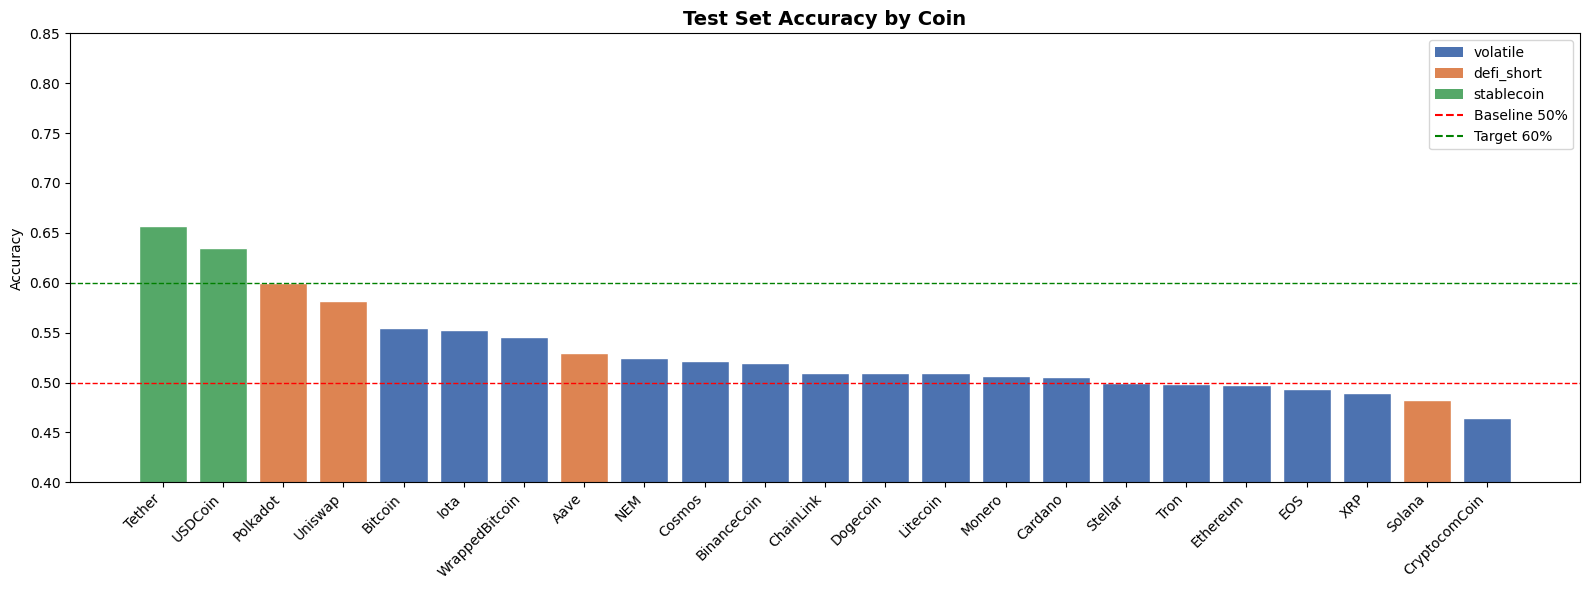

In [47]:
# ── 8.2  Bar chart of test accuracy by coin ───────────────────────────────────
color_map = {'volatile': '#4C72B0', 'defi_short': '#DD8452', 'stablecoin': '#55A868'}
colors    = [color_map[c] for c in metrics_df['category']]

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(metrics_df.index, metrics_df['test_accuracy'], color=colors, edgecolor='white')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline (50%)')
ax.axhline(0.6, color='green', linestyle='--', linewidth=1, label='Target threshold (60%)')
ax.set_title('Test Set Accuracy by Coin', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.4, 0.85)
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
legend_elements += [plt.Line2D([0],[0], color='red', linestyle='--', label='Baseline 50%'),
                    plt.Line2D([0],[0], color='green', linestyle='--', label='Target 60%')]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

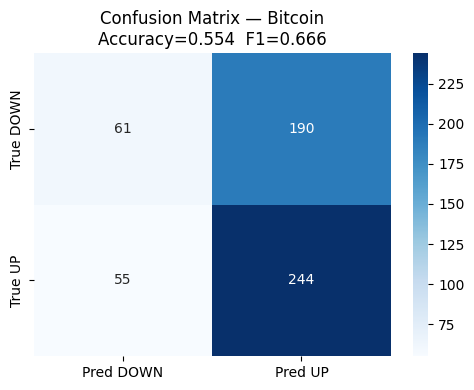


Best volatile coin: Bitcoin
              precision    recall  f1-score   support

        DOWN       0.53      0.24      0.33       251
          UP       0.56      0.82      0.67       299

    accuracy                           0.55       550
   macro avg       0.54      0.53      0.50       550
weighted avg       0.55      0.55      0.51       550



In [48]:
# ── 8.3  Confusion matrix for the best-performing volatile coin ───────────────
best_volatile = (
    metrics_df[metrics_df['category'] == 'volatile']['test_accuracy'].idxmax()
)
r = results[best_volatile]
cm = confusion_matrix(r['y_test'], r['y_pred'])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred DOWN','Pred UP'],
            yticklabels=['True DOWN','True UP'], ax=ax)
ax.set_title(f'Confusion Matrix — {best_volatile}\n'
             f'Accuracy={r["test_accuracy"]:.3f}  F1={r["test_f1"]:.3f}')
plt.tight_layout()
plt.show()

print(f'\nBest volatile coin: {best_volatile}')
print(classification_report(r['y_test'], r['y_pred'],
                             target_names=['DOWN','UP']))

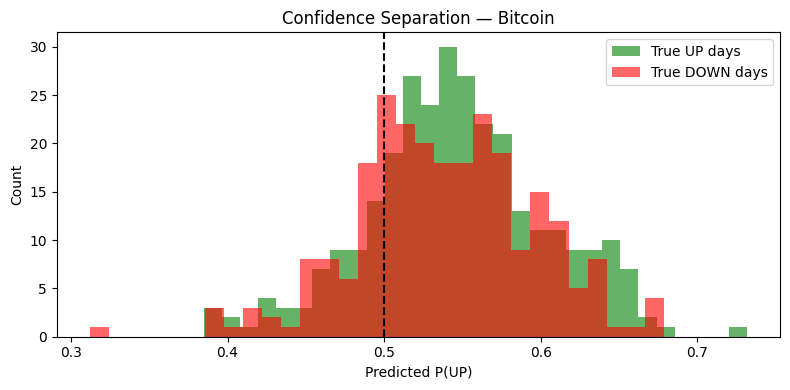

In [49]:
# ── 8.4  Prediction confidence histogram for best coin ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r['y_prob'][r['y_test'] == 1], bins=30, alpha=0.6,
        color='green', label='True UP days')
ax.hist(r['y_prob'][r['y_test'] == 0], bins=30, alpha=0.6,
        color='red', label='True DOWN days')
ax.axvline(0.5, color='black', linestyle='--')
ax.set_xlabel('Predicted P(UP)')
ax.set_ylabel('Count')
ax.set_title(f'Confidence Separation — {best_volatile}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Model Export to JSON

For exporting model weights and running inference
in JavaScript:
- Logistic Regression coefficients + intercept (for the JS dot-product)
- The feature list and scaling parameters (mean, std) for each coin
- The ensemble confidence threshold

The JS frontend loads this JSON and computes:
`probability = sigmoid(dot(scaled_features, coefs) + intercept)`

In [50]:
def extract_lr_weights(voting_clf: VotingClassifier,
                       feature_names: list[str]) -> dict | None:
    """
    Extract LogisticRegression weights from a VotingClassifier Pipeline.
    Returns None if LR is not a component (e.g. stablecoin ensemble).
    """
    for name, estimator in voting_clf.named_estimators_.items():
        if isinstance(estimator, Pipeline):
            scaler = estimator.named_steps.get('scaler')
            model  = estimator.named_steps.get('model')
            if isinstance(model, LogisticRegression):
                return {
                    'features'   : feature_names,
                    'scaler_mean': scaler.mean_.tolist(),
                    'scaler_std' : scaler.scale_.tolist(),
                    'coef'       : model.coef_[0].tolist(),
                    'intercept'  : float(model.intercept_[0]),
                }
    return None


export_data = {}

for name, r in results.items():
    weights = extract_lr_weights(r['model'], r['features_used'])
    export_data[name] = {
        'category'      : r['category'],
        'test_accuracy' : r['test_accuracy'],
        'test_precision': r['test_precision'],
        'lr_weights'    : weights,   # None for stablecoin models
        'features'      : r['features_used'],
    }

with open('model_weights.json', 'w') as f:
    json.dump(export_data, f, indent=2)

print('model_weights.json written successfully.')
print(f'Total coins exported: {len(export_data)}')

# Preview
print('\nBitcoin LR weights (first 3 features):')
btc_w = export_data['Bitcoin']['lr_weights']
for feat, coef in zip(btc_w['features'][:3], btc_w['coef'][:3]):
    print(f'  {feat:20s}: {coef:+.4f}')

model_weights.json written successfully.
Total coins exported: 23

Bitcoin LR weights (first 3 features):
  Return              : -0.0272
  LogReturn           : -0.0633
  OC_Body             : -0.0975


---
## 10. Final Prediction Function

This is the main deliverable: a function that accepts any unknown coin CSV
file, auto-detects its category, engineers the right features, and returns
an UP/DOWN prediction with confidence.

### Strategy for the unknown coin
The routing logic is identical to the regime detector in Section 2.
We use a **per-category global model** trained on all coins in that category
pooled together, which gives the model maximum generalisation to unseen coins.

In [51]:
# ── 10.1  Training one global model per category (pooled across coins) ────────────
#
# Why pooled? Individual coin models overfit to that coin's history.
# A model trained on ALL volatile coins learns general market dynamics
# and generalises better to an unseen coin.

def pool_and_train(coin_dict: dict[str, pd.DataFrame],
                   category: str,
                   k_features: int = 10) -> dict:
    """
    Concatenate feature matrices for all coins in a category,
    run feature selection, and fit a global ensemble.

    Returns dict with: model, scaler, selected_features, selector
    """
    frames = []
    for name, df in coin_dict.items():
        btc = btc_returns if (name != 'Bitcoin' and category in ('volatile','defi_short')) else None
        feat = engineer_features(df, category, btc)
        frames.append(feat)

    pooled   = pd.concat(frames).sort_index()
    X_pooled = pooled.drop(columns='Target')
    y_pooled = pooled['Target']
    # Combining into one temporary DataFrame
    combined = X_pooled.copy()
    combined['target_y'] = y_pooled

    # Dropping all NaNs and Infs at once
    combined = combined.replace([np.inf, -np.inf], np.nan).dropna()

    # Splitting them back apart
    X_pooled = combined.drop(columns=['target_y'])
    y_pooled = combined['target_y']

    # Feature selection on full pooled data
    k = min(k_features, X_pooled.shape[1])
    selector = SelectKBest(f_classif, k=k).fit(X_pooled, y_pooled)
    mask     = selector.get_support()
    feat_names = list(X_pooled.columns[mask])
    X_sel    = pd.DataFrame(selector.transform(X_pooled),
                            columns=feat_names, index=X_pooled.index)

    model = MODEL_FACTORIES[category]()
    model.fit(X_sel, y_pooled)

    return {
        'model'    : model,
        'selector' : selector,
        'features' : feat_names,
        'category' : category,
    }


print('Training pooled global models...')
global_models = {
    'volatile'   : pool_and_train(volatile_coins, 'volatile',    k_features=12),
    'defi_short' : pool_and_train(defi_coins,     'defi_short',  k_features=8),
    'stablecoin' : pool_and_train(stable_coins,   'stablecoin',  k_features=8),
}
print('All global models trained.')

Training pooled global models...
All global models trained.


In [52]:
# ── 10.2  The predict_coin() function ─────────────────────────────────────────

def predict_coin(filepath: str, verbose: bool = True) -> dict:
    """
    Master prediction function for any unknown cryptocurrency CSV file.

    Input
    -----
    filepath : path to a CSV with columns: Date, Open, High, Low, Close, Volume

    Output
    ------
    A dict containing:
      - 'prediction'  : 'UP' or 'DOWN'
      - 'confidence'  : float 0–100 (probability of UP × 100)
      - 'category'    : detected coin category
      - 'features_used': list of feature names used
      - 'last_date'   : the date of the most recent row (prediction is for day after)
      - 'signal_summary': brief human-readable explanation of the key signals
    """

    # ── Loading & cleaning ──────────────────────────────────────────────────
    df = load_and_clean(filepath)
    if len(df) < 30:
        raise ValueError(f'Too few rows ({len(df)}) — need at least 30 days of history.')

    # ── Auto-detect category (regime detection) ───────────────────────
    category = categorise_coin(df)

    # ── Engineer features ─────────────────────────────────────────────
    # Using the BTC returns as a cross-coin signal if the coin looks volatile/DeFi
    btc = btc_returns if category in ('volatile', 'defi_short') else None
    feat = engineer_features(df, category, btc)

    # The last row is the most recent complete day — predict next day
    last_row  = feat.drop(columns='Target').iloc[[-1]]
    last_date = feat.index[-1]

    # ── Applying the global model for this category ──────────────────────
    gm       = global_models[category]
    selector = gm['selector']
    model    = gm['model']
    feats    = gm['features']

    # Align features — some columns may be missing (e.g. BTC_lag1 not in index)
    # Filling missing with column mean from training (safe fallback)
    X_pred = pd.DataFrame(columns=list(last_row.columns))
    X_pred = last_row.reindex(columns=last_row.columns)

    # Applying the selector — need to pass all original features, then select
    try:
        X_sel = pd.DataFrame(
            selector.transform(X_pred),
            columns=feats
        )
    except Exception:
        # If feature set doesn't fully align (different columns), use available
        available = [f for f in feats if f in X_pred.columns]
        X_sel = X_pred[available]

    prob_up    = float(model.predict_proba(X_sel)[0, 1])
    prediction = 'UP' if prob_up >= 0.5 else 'DOWN'
    confidence = round(prob_up * 100 if prob_up >= 0.5 else (1 - prob_up) * 100, 1)

    # ── Building the summary ─────────────────────────
    signals = []
    row = feat.iloc[-1]

    if 'RSI14' in row.index:
        rsi = row['RSI14']
        if rsi < 30:   signals.append(f'RSI={rsi:.0f} (oversold → bullish signal)')
        elif rsi > 70: signals.append(f'RSI={rsi:.0f} (overbought → bearish signal)')
        else:          signals.append(f'RSI={rsi:.0f} (neutral zone)')

    if 'MA_Cross' in row.index:
        signals.append('MA5 > MA20 (uptrend)' if row['MA_Cross'] else 'MA5 < MA20 (downtrend)')

    if 'Vol_Spike' in row.index and row['Vol_Spike']:
        signals.append('Volume spike detected (1.5× 10-day avg)')

    if 'Dev_from_peg' in row.index:
        dev = row['Dev_from_peg']
        signals.append(f'Peg deviation={dev:+.4f} → '
                       f'{"below peg (mean-reversion UP likely)" if dev < 0 else "above peg (reversion DOWN likely)"}')

    if 'BB_Position' in row.index:
        bp = row['BB_Position']
        if bp < 0.2:   signals.append('Near lower Bollinger Band (potential bounce)')
        elif bp > 0.8: signals.append('Near upper Bollinger Band (potential reversal)')

    signal_summary = ' | '.join(signals) if signals else 'No strong individual signals.'

    result = {
        'prediction'    : prediction,
        'confidence'    : confidence,
        'probability_up': round(prob_up, 4),
        'category'      : category,
        'features_used' : feats,
        'last_date'     : str(last_date.date()),
        'predicting_for': 'next trading day after ' + str(last_date.date()),
        'signal_summary': signal_summary,
    }

    if verbose:
        print('═' * 60)
        print(f'  Coin file      : {os.path.basename(filepath)}')
        print(f'  Category       : {category}')
        print(f'  Last data date : {last_date.date()}')
        print(f'  Prediction     : ▲ {prediction}' if prediction == 'UP'
              else f'  Prediction     : ▼ {prediction}')
        print(f'  Confidence     : {confidence}%')
        print(f'  Key signals    : {signal_summary}')
        print('═' * 60)

    return result


print('predict_coin() function defined and ready.')

predict_coin() function defined and ready.


---
## 11. Run on Known Coins (Sanity Check)

Test the `predict_coin()` function on a few known coins to verify
the routing and prediction pipeline end-to-end.

In [53]:
test_coins = ['coin_Bitcoin.csv', 'coin_Tether.csv',
              'coin_Solana.csv',  'coin_Ethereum.csv',
              'coin_Aave.csv', 'coin_Monero.csv',
              'coin_XRP.csv',  'coin_Tron.csv',
              'coin_BinanceCoin.csv', 'coin_DogeCoin.csv',
              'coin_Iota.csv',  'coin_Cosmos.csv']

sanity_results = []
for f in test_coins:
    path = os.path.join(DATA_DIR, f)
    if os.path.exists(path):
        r = predict_coin(path, verbose=True)
        sanity_results.append(r)
    else:
        print(f'File not found: {path}')

════════════════════════════════════════════════════════════
  Coin file      : coin_Bitcoin.csv
  Category       : volatile
  Last data date : 2021-07-05
  Prediction     : ▲ UP
  Confidence     : 50.3%
  Key signals    : RSI=56 (neutral zone) | MA5 < MA20 (downtrend)
════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════
  Coin file      : coin_Tether.csv
  Category       : stablecoin
  Last data date : 2021-07-05
  Prediction     : ▼ DOWN
  Confidence     : 64.6%
  Key signals    : Peg deviation=+0.0007 → above peg (reversion DOWN likely)
════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════
  Coin file      : coin_Solana.csv
  Category       : defi_short
  Last data date : 2021-07-05
  Prediction     : ▲ UP
  Confidence     : 50.1%
  Key signals    : RSI=67 (neutral zone) | MA5 > MA20 (uptrend)
═══════════════════════════════════════════════════════

---
## 12. Running on the Test File


In [54]:
# ════════════════════════════════════════════════════════════
#  UPDATE THIS PATH when you receive the test file
# ════════════════════════════════════════════════════════════
"""
TEST_FILE_PATH = 'coin_UNKNOWN.csv'   # ← change this

if os.path.exists(TEST_FILE_PATH):
    final_prediction = predict_coin(TEST_FILE_PATH, verbose=True)
    print('\nFull result dict:')
    print(json.dumps({k: v for k, v in final_prediction.items()
                      if k != 'features_used'}, indent=2))
else:
    print(f'Test file not found at: {TEST_FILE_PATH}')
    print('Update TEST_FILE_PATH above and re-run this cell.')
"""

"\nTEST_FILE_PATH = 'coin_UNKNOWN.csv'   # ← change this\n\nif os.path.exists(TEST_FILE_PATH):\n    final_prediction = predict_coin(TEST_FILE_PATH, verbose=True)\n    print('\nFull result dict:')\n    print(json.dumps({k: v for k, v in final_prediction.items()\n                      if k != 'features_used'}, indent=2))\nelse:\n    print(f'Test file not found at: {TEST_FILE_PATH}')\n    print('Update TEST_FILE_PATH above and re-run this cell.')\n"

---
## 13. Appendix — Why These Choices?


| Decision | Choice | Reason |
|---|---|---|
| Split strategy | TimeSeriesSplit (walk-forward) | Prevents future leakage on time series data |
| Ensemble type | Soft-voting | Produces probabilities (confidence %) for dashboard |
| Feature selection | ANOVA F-score (SelectKBest) | Fit on train only; avoids leakage; interpretable |
| Stablecoin model | RF + GBM only, `class_weight='balanced'` | LogReg can't handle peg-driven class imbalance |
| DeFi model | Heavy L2 regularisation (C=0.01), shallow trees | <600 rows → high overfitting risk |
| Cross-coin feature | BTC lag-1 return | Most altcoins follow BTC with ~1 day delay |
| Category detection | Data-driven (price range / row count) | Works on any unseen coin at inference time |
| JSON export | LR weights + scaler params | Enables JS sigmoid dot-product; no Python backend needed |
